# Baby notebook: the caveats of GGH on a realistic MIMO uplink

**Purpose.** This is a short, self-contained notebook. It shows *why* GGH lattice encryption at the physical layer does not work at realistic SNR, using the same 3GPP UMi multi-user MIMO uplink as the main ("mother") notebook. It prepares the case for moving to **standardised lattice schemes** (ML-KEM, FrodoKEM), which the mother notebook implements.

**The story in one line.** GGH hides the message behind a "bad" public basis. The ciphertext grows with that badness, so after fair power normalisation Bob needs **≈ 110–120 dB** of SNR. Real links work at about 0–30 dB.

| Part | What it shows |
|---|---|
| A. GGH in one slide | keys, Hadamard ratios, error window, ciphertext size |
| B. Caveats 1–4 | (1) security vs. SNR trade-off, (2) the hidden SNR axis, (3) float32 channel, (4) LMMSE with a huge ciphertext |
| C. Sub-band Monte Carlo sweep | full-band vs. sub-band tiles ± LDPC on the **true** SNR axis, (5) why LDPC fails for large tiles, Eve check, (6) the Q-branch leak, image demo |
| D. Scenario checks from Liu et al. (2026) | keyless "channel-as-lattice" encryption (SVD + Babai), Eve's equivalent error, BDD / covering-radius check |
| E. Outlook | analytic noise budget: GGH vs. ML-KEM / FrodoKEM (the mother notebook) |

**System (same as the mother notebook).** UMi, 4 single-antenna users, 8 BS antennas (4 dual-polarised), 3.5 GHz, 128 subcarriers × 30 kHz, 14 OFDM symbols (pilots on symbols 2 and 11, so 12 data symbols), 16-QAM, ZF equalizer, perfect CSI, static users.

**Needs:** `lattice.py` and `metrics.py` from the project folder (on Colab, the first cell fetches them).

In [1]:
# Import Sionna (installs it on Colab) and fetch the project's lattice code if needed
import os, sys
if 'google.colab' in sys.modules:
    try:
        import sionna.phy
    except ImportError:
        print("Installing Sionna and restarting the runtime. Please run the cell again.")
        os.system("pip install sionna")
        os.kill(os.getpid(), 5)
    if not os.path.exists("lattice.py"):
        os.system("git clone -q -b subband https://github.com/DanielGrahamB/pqc-research.git repo && cp repo/lattice.py repo/metrics.py .")
import sionna.phy

sionna.phy.config.seed = 20
# Double precision for ALL Sionna blocks, including the 3GPP channel models (see Caveat 3).
sionna.phy.config.precision = "double"

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch, time, random, math
torch.set_default_dtype(torch.float64)

from sionna.phy import Block
from sionna.phy.mimo import StreamManagement
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, \
                            LMMSEEqualizer, ZFEqualizer, RemoveNulledSubcarriers
from sionna.phy.channel.tr38901 import Antenna, AntennaArray, UMi, UMa, RMa
from sionna.phy.channel import gen_single_sector_topology as gen_topology
from sionna.phy.channel import subcarrier_frequencies, cir_to_ofdm_channel, ApplyOFDMChannel, OFDMChannel
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.mapping import Mapper, Demapper, BinarySource
from sionna.phy.utils import ebnodb2no, sim_ber, compute_ber

from lattice import LatticeBasedEncryptor, qam16_lattice_to_normalized
# Complex error vector E = sigma*(+-1 +- j): without it the Q part is sent with no error (see Caveat 6)
LatticeBasedEncryptor.COMPLEX_ERROR_DEFAULT = True

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
cmap = plt.get_cmap("tab10")

## The simulation chain (identical to the mother notebook)

`Model` is the full-band GGH uplink: 16-QAM → GGH encryption (C = S·Bᵀ + E) → OFDM → UMi channel → ZF → Babai decryption with the private basis R. `SubbandModel` builds each GGH block from a **tile** of w subcarriers × T data symbols (lattice size n = w·T), with an optional 5G LDPC code and an interleaver around the GGH layer.

`normalize_power=True` divides the ciphertext by a fixed, public scale √P so that the transmit power is 1. Then the Eb/N0 axis is the **true** Eb/N0.

In [3]:
class Model(Block):
    def __init__(self, scenario, perfect_csi=True, interpolation_type="nn", normalize_power=False):
        super().__init__()
        self._scenario = scenario
        self._perfect_csi = perfect_csi
        self._carrier_frequency = 3.5e9
        self._fft_size = 128
        self._subcarrier_spacing = 30e3
        self._num_ofdm_symbols = 14
        self._cyclic_prefix_length = 20
        self._pilot_ofdm_symbol_indices = [2, 11]
        self._num_bs_ant = 8
        self._num_ut = 4
        self._num_ut_ant = 1
        self._num_bits_per_symbol = 4
        self._coderate = 1.0
        self._lattice_n = 512

        self._lattice_engine = LatticeBasedEncryptor(n=self._lattice_n, verbose=False)

        bs_ut_association = np.zeros([1, self._num_ut])
        bs_ut_association[0, :] = 1
        self._rx_tx_association = bs_ut_association
        self._num_tx = self._num_ut
        self._num_streams_per_tx = self._num_ut_ant

        self._rg = ResourceGrid(num_ofdm_symbols=self._num_ofdm_symbols,
                                fft_size=self._fft_size,
                                subcarrier_spacing=self._subcarrier_spacing,
                                num_tx=self._num_tx,
                                num_streams_per_tx=self._num_streams_per_tx,
                                cyclic_prefix_length=self._cyclic_prefix_length,
                                pilot_pattern="kronecker",
                                pilot_ofdm_symbol_indices=self._pilot_ofdm_symbol_indices)

        self._sm = StreamManagement(self._rx_tx_association, self._num_streams_per_tx)

        self._ut_array = AntennaArray(num_rows=1, num_cols=1, polarization="single",
                                      polarization_type="V", antenna_pattern="omni",
                                      carrier_frequency=self._carrier_frequency)

        self._bs_array = AntennaArray(num_rows=1, num_cols=int(self._num_bs_ant/2),
                                      polarization="dual", polarization_type="cross",
                                      antenna_pattern="38.901", carrier_frequency=self._carrier_frequency)

        if self._scenario == "umi":
            self._channel_model = UMi(carrier_frequency=self._carrier_frequency, o2i_model="low",
                                      ut_array=self._ut_array, bs_array=self._bs_array,
                                      direction="uplink", enable_pathloss=False, enable_shadow_fading=False)
        elif self._scenario == "uma":
            self._channel_model = UMa(carrier_frequency=self._carrier_frequency, o2i_model="low",
                                      ut_array=self._ut_array, bs_array=self._bs_array,
                                      direction="uplink", enable_pathloss=False, enable_shadow_fading=False)
        elif self._scenario == "rma":
            self._channel_model = RMa(carrier_frequency=self._carrier_frequency, ut_array=self._ut_array,
                                      bs_array=self._bs_array, direction="uplink",
                                      enable_pathloss=False, enable_shadow_fading=False)

        self._binary_source = BinarySource()
        self._k = int(self._rg.num_data_symbols * self._num_bits_per_symbol)
        self._mapper = Mapper("qam", self._num_bits_per_symbol, dtype=torch.complex128)
        self._rg_mapper = ResourceGridMapper(self._rg, dtype=torch.complex128)

        self._ofdm_channel = OFDMChannel(self._channel_model, self._rg, add_awgn=True,
                                         normalize_channel=True, return_channel=True, dtype=torch.complex128)
        self._remove_nulled_subcarriers = RemoveNulledSubcarriers(self._rg, dtype=torch.complex128)
        self._ls_est = LSChannelEstimator(self._rg, interpolation_type=interpolation_type, dtype=torch.complex128)
        # ZF, not LMMSE: Sionna's LMMSE assumes unit-power symbols; the GGH ciphertext is ~1e12x larger,
        # and the leftover inter-user interference breaks Babai decoding.
        # The attribute name is kept so the rest of the code is unchanged.
        self._lmmse_equ = ZFEqualizer(self._rg, self._sm, dtype=torch.complex128)
        self._demapper = Demapper("app", "qam", self._num_bits_per_symbol, dtype=torch.float64)

        # Optional power normalisation (true-SNR axis): transmit C/sqrt(P), receiver multiplies by sqrt(P).
        # P is a fixed public constant per key, measured once on random data.
        self._normalize_power = normalize_power
        self._tx_scale = 1.0
        if normalize_power:
            s = self._mapper(self._binary_source([64, self._lattice_n * self._num_bits_per_symbol]))
            self._lattice_engine.B = self._lattice_engine.B.to(device=s.device, dtype=torch.complex128)
            c = self._lattice_engine.encrypt(s.to(torch.complex128) * 10**0.5) / 10**0.5
            self._tx_scale = float(torch.sqrt(torch.mean(torch.abs(c) ** 2)))

    def babai_decode_internal(self, x_hat_reshaped):
        device = x_hat_reshaped.device
        x_input = x_hat_reshaped.to(dtype=torch.complex128)
        R = self._lattice_engine.R.to(device=device, dtype=torch.complex128)
        R_inv = torch.linalg.pinv(R)
        B_inv = self._lattice_engine.B_inv.to(device=device, dtype=torch.complex128)

        Y = torch.matmul(x_input, R_inv.T)
        Y_integer = torch.round(Y.real) + 1j * torch.round(Y.imag)

        lattice_point = torch.matmul(Y_integer, R.T)
        S_hat = torch.matmul(lattice_point, B_inv.T)
        return S_hat

    def new_topology(self, batch_size):
        self._channel_model.reset_topology()
        topology = gen_topology(batch_size, self._num_ut, self._scenario, min_ut_velocity=0.0, max_ut_velocity=0.0)
        self._channel_model.set_topology(*topology)

    def call(self, batch_size, ebno_db):
        self.new_topology(batch_size)
        no = ebnodb2no(ebno_db, self._num_bits_per_symbol, self._coderate, self._rg)
        b = self._binary_source([batch_size, self._num_tx, self._num_streams_per_tx, self._k])

        x = self._mapper(b)
        x_shape = x.shape
        x_reshaped = torch.reshape(x, (-1, self._lattice_n))
        self._lattice_engine.B = self._lattice_engine.B.to(device=x.device, dtype=torch.complex128)
        qs = torch.sqrt(torch.tensor(10.0, dtype=torch.float64, device=x.device))
        x_enc_blocks = self._lattice_engine.encrypt(x_reshaped.to(torch.complex128) * qs) / qs
        x_enc = torch.reshape(x_enc_blocks, x_shape) / self._tx_scale

        x_rg = self._rg_mapper(x_enc)
        y, h = self._ofdm_channel(x_rg, no)

        if self._perfect_csi:
            h_hat = self._remove_nulled_subcarriers(h)
            err_var = torch.tensor(0.0, dtype=torch.complex128, device=y.device)
        else:
            h_hat, err_var = self._ls_est(y, no)

        x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no)

        qam_scale = torch.sqrt(torch.tensor(10.0, dtype=torch.float64, device=x_hat.device))
        x_hat_lattice_domain = x_hat * qam_scale * self._tx_scale

        x_hat_shape = x_hat.shape
        x_hat_reshaped = torch.reshape(x_hat_lattice_domain, (-1, self._lattice_n))
        x_dec_lattice_blocks = self.babai_decode_internal(x_hat_reshaped)
        x_dec_lattice = torch.reshape(x_dec_lattice_blocks, x_hat_shape)

        x_dec = qam16_lattice_to_normalized(x_dec_lattice)
        llr = self._demapper(x_dec.to(torch.complex128), no_eff.to(torch.float64))
        b_hat = torch.where(llr > 0, torch.tensor(1.0, dtype=torch.float64, device=llr.device), torch.tensor(0.0, dtype=torch.float64, device=llr.device))

        return b, b_hat

In [4]:
# ---------- Tile layout: which resource elements go into each lattice block ----------
def build_tile_perm(rg, band_width, band_time):
    """Return (perm, inv_perm, n_sub, num_tiles).
    perm reorders the data symbols (Sionna order) so that each consecutive group of
    n_sub = band_width * band_time symbols is one tile (w subcarriers x T data symbols)."""
    mask = rg.pilot_pattern.mask
    mask = mask.cpu().numpy() if hasattr(mask, "cpu") else np.asarray(mask)
    mask = mask[0, 0]                                   # [num_ofdm_symbols, num_subcarriers]
    coords = np.argwhere(mask == 0)                     # data REs, row-major = Sionna data order
    assert len(coords) == rg.num_data_symbols, "data layout check failed"

    sym_ids = np.unique(coords[:, 0])
    t_rank = np.searchsorted(sym_ids, coords[:, 0])     # 0..(num data symbols - 1)
    sc = coords[:, 1]
    n_sym, n_sc = len(sym_ids), int(sc.max()) + 1
    assert n_sc % band_width == 0, f"band_width must divide {n_sc}"
    assert n_sym % band_time == 0, f"band_time must divide {n_sym}"

    tile_id = (t_rank // band_time) * (n_sc // band_width) + (sc // band_width)
    perm = np.argsort(tile_id, kind="stable")           # group REs tile by tile
    inv_perm = np.argsort(perm)
    n_sub = band_width * band_time
    return perm, inv_perm, n_sub, len(perm) // n_sub


def babai_decode_with(engine, x, use_public_basis=False):
    """Babai round-off for one tile. use_public_basis=True simulates Eve (only has B)."""
    dev = x.device
    x = x.to(torch.complex128)
    R = (engine.B if use_public_basis else engine.R).to(device=dev, dtype=torch.complex128)
    R_inv = torch.linalg.pinv(R)
    B_inv = engine.B_inv.to(device=dev, dtype=torch.complex128)
    Y = torch.matmul(x, R_inv.T)
    Y_int = torch.round(Y.real) + 1j * torch.round(Y.imag)
    return torch.matmul(torch.matmul(Y_int, R.T), B_inv.T)

In [5]:
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder

class SubbandModel(Model):
    """Same system as Model, but GGH blocks are built from sub-band tiles.

    band_width      : subcarriers per tile (must divide 128)
    band_time       : data OFDM symbols per tile (must divide 12)
    distinct_bases  : True -> each tile has its own key pair (recommended for small tiles)
    use_ldpc        : outer 5G LDPC code (+ random interleaver) around the GGH layer
    coderate        : LDPC code rate
    normalize_power : scale ciphertext to unit power (fair across different n)
    eve             : decode with the public basis B (eavesdropper)
    """
    def __init__(self, scenario, band_width=32, band_time=12, distinct_bases=True,
                 use_ldpc=False, coderate=0.5, normalize_power=False, eve=False,
                 perfect_csi=True, llr_mag=3.0, seed=0):
        super().__init__(scenario, perfect_csi=perfect_csi)
        self._perm, self._inv_perm, self._n_sub, self._num_tiles = \
            build_tile_perm(self._rg, band_width, band_time)
        self._perm_t = torch.tensor(self._perm)
        self._inv_perm_t = torch.tensor(self._inv_perm)
        self._eve = eve
        self._normalize_power = normalize_power
        self._llr_mag = llr_mag

        # Keys: one engine per tile, or one shared engine
        n_engines = self._num_tiles if distinct_bases else 1
        self._engines = [LatticeBasedEncryptor(n=self._n_sub, verbose=False) for _ in range(n_engines)]

        # Fixed power scale per engine (public constant, known to the receiver)
        self._scale = []
        for eng in self._engines:
            s = self._mapper(self._binary_source([256, self._n_sub * self._num_bits_per_symbol]))
            eng.B = eng.B.to(device=s.device, dtype=torch.complex128)
            c = eng.encrypt(s.to(torch.complex128) * 10**0.5) / 10**0.5
            self._scale.append(float(torch.sqrt(torch.mean(torch.abs(c) ** 2))) if normalize_power else 1.0)

        # Optional outer LDPC code
        self._use_ldpc = use_ldpc
        self._n_coded = int(self._rg.num_data_symbols * self._num_bits_per_symbol)
        if use_ldpc:
            self._coderate = coderate
            self._k = int(self._n_coded * coderate)
            self._encoder = LDPC5GEncoder(self._k, self._n_coded, num_bits_per_symbol=self._num_bits_per_symbol)
            self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)
            g = torch.Generator().manual_seed(seed)
            self._ilv = torch.randperm(self._n_coded, generator=g)   # spreads sub-band bursts
            self._ilv_inv = torch.argsort(self._ilv)
        else:
            self._coderate = 1.0
            self._k = self._n_coded

    def _engine(self, g):
        return self._engines[g if len(self._engines) > 1 else 0]

    def _to_tiles(self, x):          # [..., num_data] -> [..., num_tiles, n_sub]
        x = x[..., self._perm_t.to(x.device)]
        return x.reshape(*x.shape[:-1], self._num_tiles, self._n_sub)

    def _from_tiles(self, x):        # inverse of _to_tiles
        x = x.reshape(*x.shape[:-2], self._num_tiles * self._n_sub)
        return x[..., self._inv_perm_t.to(x.device)]

    def run_bits(self, b, ebno_db, new_channel=True):
        batch_size = b.shape[0]
        if new_channel:
            self.new_topology(batch_size)
        no = ebnodb2no(ebno_db, self._num_bits_per_symbol, self._coderate, self._rg)

        # --- transmitter ---
        c_bits = b
        if self._use_ldpc:
            c_bits = self._encoder(b)[..., self._ilv.to(b.device)]
        x = self._mapper(c_bits).to(torch.complex128)
        xt = self._to_tiles(x)
        enc = torch.empty_like(xt)
        for g in range(self._num_tiles):
            eng = self._engine(g)
            eng.B = eng.B.to(device=x.device, dtype=torch.complex128)
            blk = xt[..., g, :].reshape(-1, self._n_sub)
            enc[..., g, :] = (eng.encrypt(blk * 10**0.5) / 10**0.5 / self._scale[g if len(self._scale) > 1 else 0]).reshape(xt[..., g, :].shape)
        x_enc = self._from_tiles(enc)

        # --- channel ---
        y, h = self._ofdm_channel(self._rg_mapper(x_enc), no)
        if self._perfect_csi:
            h_hat = self._remove_nulled_subcarriers(h)
            err_var = torch.tensor(0.0, dtype=torch.complex128, device=y.device)
        else:
            h_hat, err_var = self._ls_est(y, no)
        x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no)

        # --- receiver: Babai per tile ---
        qam_scale = torch.sqrt(torch.tensor(10.0, dtype=torch.float64, device=x_hat.device))
        xh = self._to_tiles(x_hat)
        dec = torch.empty_like(xh)
        for g in range(self._num_tiles):
            s = self._scale[g if len(self._scale) > 1 else 0]
            blk = xh[..., g, :].reshape(-1, self._n_sub) * s * qam_scale
            dec[..., g, :] = babai_decode_with(self._engine(g), blk, self._eve).reshape(xh[..., g, :].shape)
        x_dec = qam16_lattice_to_normalized(self._from_tiles(dec))

        llr = self._demapper(x_dec.to(torch.complex128), no_eff.to(torch.float64))
        hard = (llr > 0).to(torch.float64)
        if not self._use_ldpc:
            return b, hard
        # Babai gives hard decisions -> fixed-size LLRs, de-interleave, decode
        llr_h = (2.0 * hard - 1.0) * self._llr_mag
        llr_h = llr_h[..., self._ilv_inv.to(llr_h.device)]
        return b, self._decoder(llr_h)

    def call(self, batch_size, ebno_db):
        b = self._binary_source([batch_size, self._num_tx, self._num_streams_per_tx, self._k])
        return self.run_bits(b, ebno_db)

## Part A. GGH in one slide

- **Keys.** The private basis R = k·I + small noise is "good": nearly orthogonal, Hadamard ratio HR(R) ≥ 0.8. The public basis B = R·U, with U a random unimodular matrix, is "bad": HR(B) ≤ 10⁻³.
- **Encrypt.** C = S·Bᵀ + E, with S the integer 16-QAM levels (±1, ±3) and E = ±σ.
- **Decrypt (Bob).** Babai round-off in R: round(C·R⁻ᵀ)·Rᵀ·B⁻ᵀ. This is correct if every coordinate of (E + noise)·R⁻ᵀ stays below 1/2.
- **Error window.** 1/(2ρ_B) < σ < 1/(2ρ_R), where ρ = max row ℓ1-norm of the inverse basis. Below the window Eve can read the message; above it Bob fails.
- **Eve.** She has only B, so Babai in B returns garbage.

The table shows what this costs: the ciphertext is **10¹⁰–10¹³ times** stronger than a 16-QAM symbol (100–135 dB), and the exact value varies from key to key.

In [6]:
lv = torch.tensor([-3., -1., 1., 3.])
print(f"{'n':>5s}{'k=R[0,0]':>9s}{'HR(R)':>8s}{'HR(B)':>10s}{'sigma':>10s}{'window':>24s}{'max|B|':>10s}{'P_cipher':>11s}{'keygen':>8s}")
for n in [96, 192, 384, 512]:
    t = time.time()
    eng = LatticeBasedEncryptor(n=n, verbose=False)
    S = (lv[torch.randint(0, 4, (64, n))] + 1j * lv[torch.randint(0, 4, (64, n))]).to(torch.complex128)
    P = (eng.encrypt(S).abs() ** 2).mean().item() / 10          # relative to a unit-power 16-QAM symbol
    i = eng.info
    print(f"{n:5d}{eng.R[0,0].real.item():9.0f}{i['hr_R']:8.3f}{i['hr_B']:10.1e}{eng.sigma:10.2e}"
          f"   [{i['sigma_min_secure']:.1e}, {i['sigma_max_correct']:.1e}]{eng.B.abs().max().item():10.1e}"
          f"{10*np.log10(P):8.1f} dB{time.time()-t:7.1f}s")

    n k=R[0,0]   HR(R)     HR(B)     sigma                  window    max|B|   P_cipher  keygen
   96       24   0.863   7.5e-04  1.26e+00   [2.6e-05, 1.4e+00]   5.1e+05   100.6 dB    0.0s
  192       31   0.853   5.8e-04  1.21e+00   [2.1e-05, 1.3e+00]   4.9e+06   115.2 dB    0.0s


  384       49   0.866   4.4e-04  1.47e+00   [2.6e-06, 1.6e+00]   2.0e+07   125.1 dB    0.2s


  512       49   0.832   4.8e-04  9.98e-01   [4.0e-06, 1.1e+00]   4.9e+06   114.0 dB    0.5s


## Part B. Caveats of GGH at the physical layer

### Caveat 1: more security means more SNR (the core problem)

GGH has **no modulus**. The ciphertext is a combination of the long vectors of B, so a "worse" (more secure) public basis gives a **larger** ciphertext. With fair power normalisation (transmit C/√P), the noise that reaches Babai grows by the same factor, so the SNR needed grows with security.

The sweep below changes the mixing strength of U (`rounds` × `max_coeff`) for n = 192 (the size of a 16 × 12 tile) over AWGN. It records HR(B), the ciphertext power and the smallest **true** Es/N0 at which all blocks decrypt.

rounds=1 coeff=1  HR(B)=5.2e-01  ciphertext power=  36.0 dB  required true Es/N0=  35.0 dB  NOT secure


rounds=1 coeff=2  HR(B)=3.1e-01  ciphertext power=  46.9 dB  required true Es/N0=  45.0 dB  NOT secure


rounds=1 coeff=3  HR(B)=2.2e-01  ciphertext power=  48.6 dB  required true Es/N0=  50.0 dB  NOT secure


rounds=2 coeff=1  HR(B)=3.2e-01  ciphertext power=  40.5 dB  required true Es/N0=  40.0 dB  NOT secure


rounds=2 coeff=2  HR(B)=1.1e-01  ciphertext power=  54.1 dB  required true Es/N0=  55.0 dB  NOT secure


...

rounds=4 coeff=1  HR(B)=1.2e-01  ciphertext power=  49.3 dB  required true Es/N0=  47.5 dB  NOT secure


rounds=4 coeff=2  HR(B)=1.2e-02  ciphertext power=  79.5 dB  required true Es/N0=  80.0 dB  NOT secure


rounds=4 coeff=3  HR(B)=1.7e-03  ciphertext power= 121.3 dB  required true Es/N0= 122.5 dB  NOT secure


rounds=5 coeff=1  HR(B)=7.1e-02  ciphertext power=  53.5 dB  required true Es/N0=  55.0 dB  NOT secure


rounds=5 coeff=2  HR(B)=3.7e-03  ciphertext power=  86.9 dB  required true Es/N0=  87.5 dB  NOT secure
rounds=5 coeff=3  HR(B)=5.2e-04  ciphertext power= 114.2 dB  required true Es/N0= 112.5 dB  secure


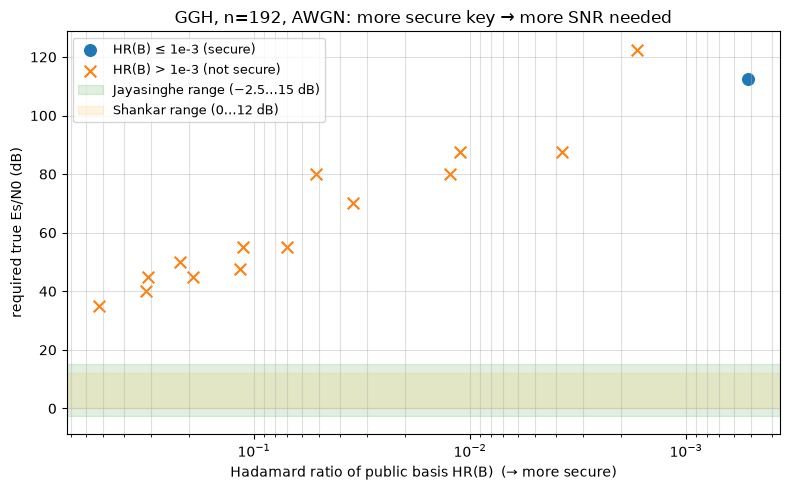

In [7]:
def ggh_required_snr(eng, n, snr_grid, num_blocks=64):
    """Smallest true Es/N0 (dB) on snr_grid at which all num_blocks blocks decrypt without error."""
    lv = torch.tensor([-3., -1., 1., 3.], dtype=torch.float64)
    S = (lv[torch.randint(0, 4, (num_blocks, n))] + 1j * lv[torch.randint(0, 4, (num_blocks, n))]).to(torch.complex128)
    C = eng.encrypt(S)                                     # lattice domain (integer QAM levels)
    P = (C.abs() ** 2).mean().item()                       # transmit C/sqrt(P) -> unit power
    R = eng.R.to(torch.complex128); R_inv = torch.linalg.pinv(R); B_inv = eng.B_inv
    for snr in snr_grid:
        no = 10 ** (-snr / 10)
        N = np.sqrt(no * P / 2) * (torch.randn(C.shape, dtype=torch.float64) + 1j * torch.randn(C.shape, dtype=torch.float64))
        Y = (C + N) @ R_inv.T
        S_hat = ((torch.round(Y.real) + 1j * torch.round(Y.imag)) @ R.T) @ B_inv.T
        if bool(((S_hat - S).abs() < 0.5).all()):
            return snr, P
    return float("nan"), P

SEC = []
snr_grid = np.arange(0, 200.1, 2.5)
n_sec = 192
for rounds in [1, 2, 3, 4, 5]:
    for max_coeff in [1, 2, 3]:
        eng = LatticeBasedEncryptor(n=n_sec, rounds=rounds, max_coeff=max_coeff, verbose=False)
        snr_req, P = ggh_required_snr(eng, n_sec, snr_grid)
        SEC.append(dict(rounds=rounds, max_coeff=max_coeff, hr_B=eng.info["hr_B"], P_db=10 * np.log10(P / 10),
                        snr_req=snr_req, secure=eng.info["hr_B"] <= 1e-3))
        print(f"rounds={rounds} coeff={max_coeff}  HR(B)={eng.info['hr_B']:.1e}  "
              f"ciphertext power={10*np.log10(P/10):6.1f} dB  required true Es/N0={snr_req:6.1f} dB  "
              f"{'secure' if eng.info['hr_B'] <= 1e-3 else 'NOT secure'}")

fig, ax = plt.subplots(figsize=(8, 5))
for sec_flag, mk, lab in [(True, "o", "HR(B) ≤ 1e-3 (secure)"), (False, "x", "HR(B) > 1e-3 (not secure)")]:
    pts = [r for r in SEC if r["secure"] == sec_flag]
    ax.scatter([r["hr_B"] for r in pts], [r["snr_req"] for r in pts], marker=mk, s=70, label=lab)
ax.set_xscale("log"); ax.invert_xaxis()
ax.axhspan(-2.5, 15, color="green", alpha=0.12, label="Jayasinghe range (−2.5…15 dB)")
ax.axhspan(0, 12, color="orange", alpha=0.12, label="Shankar range (0…12 dB)")
ax.set_xlabel("Hadamard ratio of public basis HR(B)  (→ more secure)")
ax.set_ylabel("required true Es/N0 (dB)")
ax.set_title(f"GGH, n={n_sec}, AWGN: more secure key → more SNR needed")
ax.grid(True, which="both", alpha=0.4); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### Caveat 2: the hidden SNR axis

Sionna's `ebnodb2no` sets the noise level for **unit-power** symbols. If the GGH ciphertext is sent without normalisation, its huge power (≈ +110 dB) is silently added to the SNR. The plot then shows decryption at a "labelled" 0–10 dB, while the physical SNR is about 120 dB.

Below, the same 16 × 12 sub-band system runs twice in the UMi uplink, without and with power normalisation. **The horizontal gap between the two curves is the ciphertext power.** Every GGH curve in papers that do not normalise power should be read with this shift in mind.


=== UMi | sub-band 16x12 (n=192) | labelled axis (ciphertext power not counted) ===


EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------


      0.0 | 3.2196e-04 | 1.2500e-02 |        2532 |     7864320 |           16 |        1280 |         2.3 |reached max iterations


     10.0 | 0.0000e+00 | 0.0000e+00 |           0 |     7864320 |            0 |        1280 |         2.1 |reached max iterations

Simulation stopped as no error occurred @ EbNo = 10.0 dB.


=== UMi | sub-band 16x12 (n=192) | true axis (transmit power = 1) ===


EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 5.0061e-01 | 1.0000e+00 |      393693 |      786432 |          128 |         128 |         0.2 |reached target block errors
     10.0 | 4.9939e-01 | 1.0000e+00 |      392737 |      786432 |          128 |         128 |         0.2 |reached target block errors


...

     90.0 | 3.7904e-01 | 1.0000e+00 |      298091 |      786432 |          128 |         128 |         0.2 |reached target block errors


    100.0 | 1.5442e-01 | 1.0000e+00 |      121442 |      786432 |          128 |         128 |         0.2 |reached target block errors


    110.0 | 1.9173e-02 | 5.0781e-01 |       15078 |      786432 |           65 |         128 |         0.2 |reached target block errors


    120.0 | 6.3451e-05 | 2.3437e-03 |         499 |     7864320 |            3 |        1280 |         2.0 |reached max iterations


    130.0 | 0.0000e+00 | 0.0000e+00 |           0 |     7864320 |            0 |        1280 |         2.4 |reached max iterations

Simulation stopped as no error occurred @ EbNo = 130.0 dB.



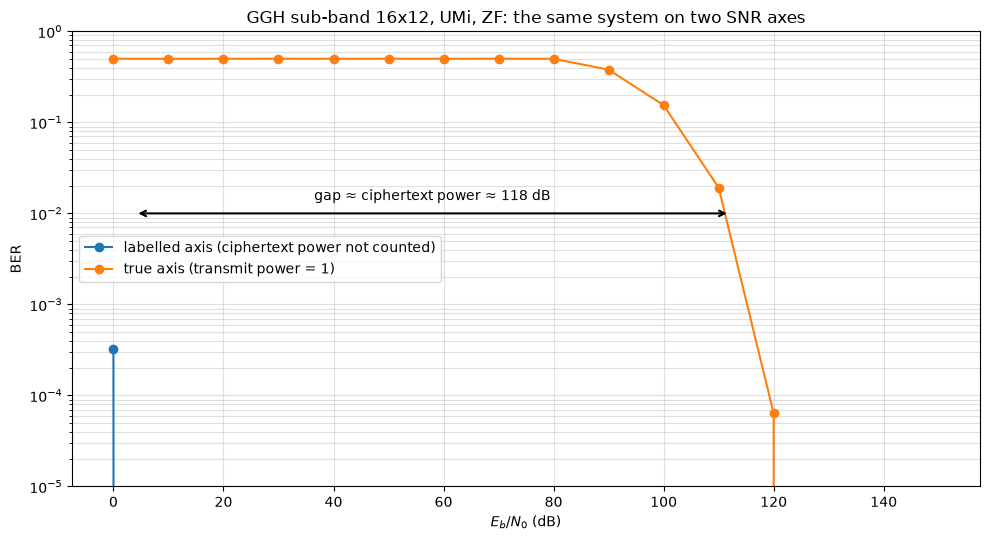

In [8]:
AX = {"ebno_db": list(np.arange(0, 151, 10.0)), "results": {}}
for label, norm in [("labelled axis (ciphertext power not counted)", False), ("true axis (transmit power = 1)", True)]:
    print(f"\n=== UMi | sub-band 16x12 (n=192) | {label} ===")
    m = SubbandModel("umi", band_width=16, band_time=12, distinct_bases=True, normalize_power=norm)
    if torch.cuda.is_available(): m.cuda()
    m._channel_model.allocate_topology_tensors(batch_size=32, num_bs=1, num_ut=m._num_ut)
    ber, bler = sim_ber(m, AX["ebno_db"], batch_size=32, max_mc_iter=10, num_target_block_errors=50,
                        target_bler=1e-3, compile_mode=None)
    AX["results"][label] = (ber.cpu().numpy(), bler.cpu().numpy())
    if norm:
        AX["P_db"] = 10 * np.log10(np.mean(np.square(m._scale)))

fig, ax = plt.subplots(figsize=(10, 5.5))
for i, (label, (ber, _)) in enumerate(AX["results"].items()):
    ax.semilogy(AX["ebno_db"], ber, "-o", color=cmap(i), label=label)
ax.annotate("", xy=(112, 1e-2), xytext=(4, 1e-2), arrowprops=dict(arrowstyle="<->", lw=1.5))
ax.text(58, 1.4e-2, f"gap ≈ ciphertext power ≈ {AX['P_db']:.0f} dB", ha="center")
ax.set_xlabel(r"$E_b/N_0$ (dB)"); ax.set_ylabel("BER"); ax.set_ylim(1e-5, 1); ax.grid(True, which="both", alpha=0.4)
ax.set_title("GGH sub-band 16x12, UMi, ZF: the same system on two SNR axes"); ax.legend()
plt.tight_layout(); plt.show()

### Caveat 3: GGH needs double precision everywhere

Sionna 2.x builds the 3GPP channel models in **single precision** unless told otherwise. Float32 has a relative error of ~10⁻⁷. On a ciphertext of size ~10⁷ that is an absolute error of ~1–4, far above the Babai margin (~0.35). Bob then fails **with no noise at all**.

ML-KEM / FrodoKEM values are at most a few thousand, so float32 would be harmless there. This is another symptom of GGH's unbounded ciphertext.

In [9]:
for prec in ["single", "double"]:
    sionna.phy.config.precision = prec            # every block below is built in this precision
    m = SubbandModel("umi", band_width=16, band_time=12, distinct_bases=True)
    if torch.cuda.is_available(): m.cuda()
    m._channel_model.allocate_topology_tensors(batch_size=8, num_bs=1, num_ut=m._num_ut)
    with torch.no_grad():
        b, b_hat = m(8, torch.tensor(200.0, dtype=torch.float64))     # practically noiseless
    print(f"channel model precision = {prec:6s} -> Bob's BER with no noise = {compute_ber(b, b_hat).item():.2e}")
sionna.phy.config.precision = "double"

channel model precision = single -> Bob's BER with no noise = 1.56e-03


channel model precision = double -> Bob's BER with no noise = 0.00e+00


### Caveat 4: LMMSE equalisation breaks with an unnormalised ciphertext

Sionna's LMMSE equalizer assumes unit-power symbols, G = (HᴴH + N₀I)⁻¹Hᴴ. With a ciphertext ~10¹¹× stronger, the regularisation term leaves inter-user interference proportional to the signal. Babai then fails for whole user streams until the labelled SNR is very high (an artificial 50–60 dB waterfall). ZF has no such term. With normalised power, LMMSE and ZF behave alike.


=== UMi | sub-band 16x12 | unnormalised ciphertext | ZF ===


EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------


      0.0 | 6.8156e-05 | 9.3750e-03 |         536 |     7864320 |           12 |        1280 |         2.1 |reached max iterations


     10.0 | 0.0000e+00 | 0.0000e+00 |           0 |     7864320 |            0 |        1280 |         2.0 |reached max iterations

Simulation stopped as no error occurred @ EbNo = 10.0 dB.


=== UMi | sub-band 16x12 | unnormalised ciphertext | LMMSE (assumes unit-power symbols) ===


EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 4.9938e-01 | 1.0000e+00 |      392732 |      786432 |          128 |         128 |         0.3 |reached target block errors


...

     30.0 | 4.9525e-01 | 1.0000e+00 |      389480 |      786432 |          128 |         128 |         0.3 |reached target block errors


     40.0 | 2.7928e-01 | 1.0000e+00 |      219635 |      786432 |          128 |         128 |         0.3 |reached target block errors


     50.0 | 1.8429e-02 | 4.8438e-01 |       14493 |      786432 |           62 |         128 |         0.3 |reached target block errors


     60.0 | 3.9800e-05 | 2.3437e-03 |         313 |     7864320 |            3 |        1280 |         2.6 |reached max iterations


     70.0 | 0.0000e+00 | 0.0000e+00 |           0 |     7864320 |            0 |        1280 |         2.6 |reached max iterations

Simulation stopped as no error occurred @ EbNo = 70.0 dB.



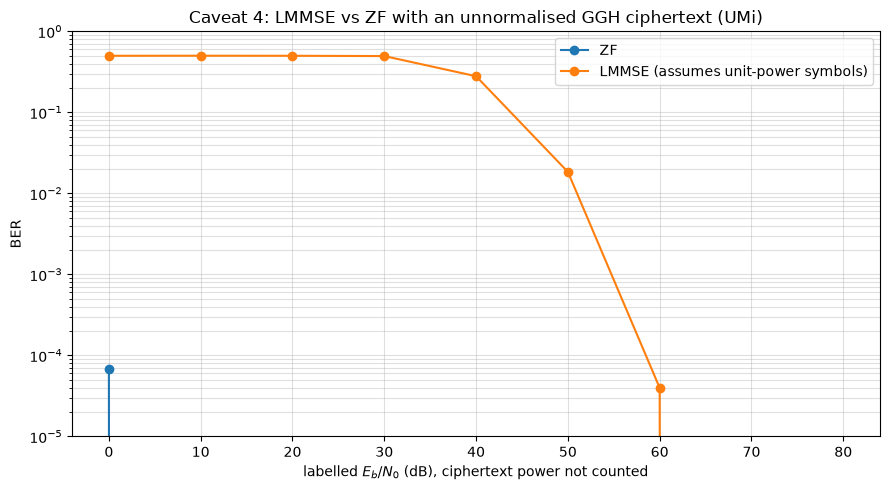

In [10]:
EQ = {"ebno_db": list(np.arange(0, 81, 10.0)), "results": {}}
for label in ["ZF", "LMMSE (assumes unit-power symbols)"]:
    print(f"\n=== UMi | sub-band 16x12 | unnormalised ciphertext | {label} ===")
    m = SubbandModel("umi", band_width=16, band_time=12, distinct_bases=True)          # original (labelled) setup
    if label.startswith("LMMSE"):
        m._lmmse_equ = LMMSEEqualizer(m._rg, m._sm, dtype=torch.complex128)
    if torch.cuda.is_available(): m.cuda()
    m._channel_model.allocate_topology_tensors(batch_size=32, num_bs=1, num_ut=m._num_ut)
    ber, _ = sim_ber(m, EQ["ebno_db"], batch_size=32, max_mc_iter=10, num_target_block_errors=50,
                     target_bler=1e-3, compile_mode=None)
    EQ["results"][label] = ber.cpu().numpy()
fig, ax = plt.subplots(figsize=(9, 5))
for i, (label, ber) in enumerate(EQ["results"].items()):
    ax.semilogy(EQ["ebno_db"], ber, "-o", color=cmap(i), label=label)
ax.set_xlabel(r"labelled $E_b/N_0$ (dB), ciphertext power not counted"); ax.set_ylabel("BER")
ax.set_ylim(1e-5, 1); ax.grid(True, which="both", alpha=0.4); ax.legend()
ax.set_title("Caveat 4: LMMSE vs ZF with an unnormalised GGH ciphertext (UMi)")
plt.tight_layout(); plt.show()

## Part C. Sub-band Monte Carlo sweep on the true SNR axis (UMi)

**Idea of sub-banding.** A full-band GGH block spans all 128 subcarriers, so one faded subcarrier can break the whole block. A sub-band tile (w subcarriers × T data symbols) sits in a narrower part of the band. Each tile has its own key.

**Fair comparisons.** 128 × 3 and 32 × 12 have the same lattice size (n = 384); only the shape changes. 128 × 4 with one shared key is the original full-band model (n = 512).

All runs use ZF, double precision and **normalised transmit power**, so the x-axis is the true Eb/N0. Expect the waterfall at about 100–120 dB.


=== UMi | Full-band 128x4 (n=512, one key) | uncoded | true SNR ===


EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     80.0 | 4.9910e-01 | 1.0000e+00 |      392505 |      786432 |          128 |         128 |         0.4 |reached target block errors


     90.0 | 4.9744e-01 | 1.0000e+00 |      391204 |      786432 |          128 |         128 |         0.4 |reached target block errors


    100.0 | 6.0563e-02 | 5.7031e-01 |       47629 |      786432 |           73 |         128 |         0.4 |reached target block errors


    110.0 | 1.7306e-04 | 4.2969e-03 |        2722 |    15728640 |           11 |        2560 |         7.3 |reached max iterations


...

     90.0 | 4.3585e-01 | 1.0000e+00 |      171385 |      393216 |          128 |         128 |         2.5 |reached target block errors


    100.0 | 3.1000e-01 | 1.0000e+00 |      121898 |      393216 |          128 |         128 |         2.5 |reached target block errors


    110.0 | 2.4658e-01 | 1.0000e+00 |       96960 |      393216 |          128 |         128 |         3.3 |reached target block errors


    120.0 | 3.5693e-03 | 6.6406e-02 |        8421 |     2359296 |           51 |         768 |        15.1 |reached target block errors


    130.0 | 0.0000e+00 | 0.0000e+00 |           0 |     7864320 |            0 |        2560 |        50.8 |reached max iterations

Simulation stopped as no error occurred @ EbNo = 130.0 dB.


Total time: 533 s


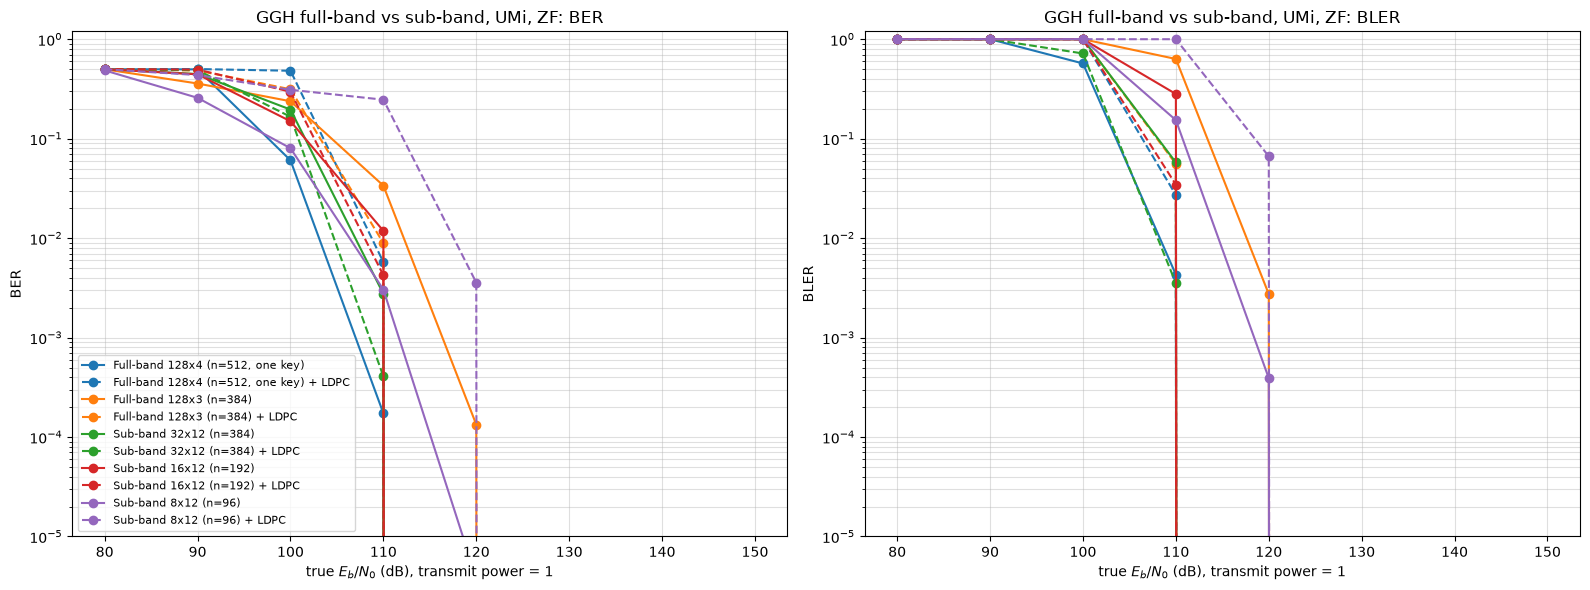

config                                           80       90      100      110      120      130      140      150
Full-band 128x4 (n=512, one key)            5.0e-01  5.0e-01  6.1e-02  1.7e-04  0.0e+00  0.0e+00  0.0e+00  0.0e+00
Full-band 128x4 (n=512, one key) +LDPC      5.0e-01  5.0e-01  4.8e-01  5.7e-03  0.0e+00  0.0e+00  0.0e+00  0.0e+00
Full-band 128x3 (n=384)                     5.0e-01  3.6e-01  2.4e-01  3.4e-02  1.3e-04  0.0e+00  0.0e+00  0.0e+00
Full-band 128x3 (n=384) +LDPC               5.0e-01  4.8e-01  3.1e-01  8.9e-03  0.0e+00  0.0e+00  0.0e+00  0.0e+00
Sub-band 32x12 (n=384)                      5.0e-01  4.5e-01  2.0e-01  2.7e-03  0.0e+00  0.0e+00  0.0e+00  0.0e+00
Sub-band 32x12 (n=384) +LDPC                5.0e-01  4.9e-01  1.7e-01  4.1e-04  0.0e+00  0.0e+00  0.0e+00  0.0e+00
Sub-band 16x12 (n=192)                      5.0e-01  4.4e-01  1.5e-01  1.2e-02  0.0e+00  0.0e+00  0.0e+00  0.0e+00
Sub-band 16x12 (n=192) +LDPC                5.0e-01  5.0e-01  3.0e-01  4.2e-03  

In [11]:
SB_CONFIGS = [("Full-band 128x4 (n=512, one key)", 128, 4, False),
              ("Full-band 128x3 (n=384)",          128, 3, True),
              ("Sub-band 32x12 (n=384)",            32, 12, True),
              ("Sub-band 16x12 (n=192)",            16, 12, True),
              ("Sub-band 8x12 (n=96)",               8, 12, True)]
SB = {"ebno_db": list(np.arange(80, 151, 10.0)), "batch_size": 32, "results": {}}
start = time.time()
for label, w, T, distinct in SB_CONFIGS:
    for use_ldpc in [False, True]:
        print(f"\n=== UMi | {label} | {'LDPC 1/2' if use_ldpc else 'uncoded'} | true SNR ===")
        m = SubbandModel("umi", band_width=w, band_time=T, distinct_bases=distinct,
                         use_ldpc=use_ldpc, normalize_power=True)
        if torch.cuda.is_available(): m.cuda()
        m._channel_model.allocate_topology_tensors(batch_size=SB["batch_size"], num_bs=1, num_ut=m._num_ut)
        ber, bler = sim_ber(m, SB["ebno_db"], batch_size=SB["batch_size"], max_mc_iter=20,
                            num_target_block_errors=50, target_bler=1e-3, compile_mode=None)
        SB["results"][(label, use_ldpc)] = (ber.cpu().numpy(), bler.cpu().numpy())
print(f"\nTotal time: {time.time()-start:.0f} s")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
for i, (label, *_ ) in enumerate(SB_CONFIGS):
    for use_ldpc, ls in [(False, "-"), (True, "--")]:
        ber, bler = SB["results"][(label, use_ldpc)]
        tag = label + (" + LDPC" if use_ldpc else "")
        ax[0].semilogy(SB["ebno_db"], ber, ls, marker="o", color=cmap(i), label=tag)
        ax[1].semilogy(SB["ebno_db"], bler, ls, marker="o", color=cmap(i), label=tag)
for a, name in zip(ax, ["BER", "BLER"]):
    a.set_xlabel(r"true $E_b/N_0$ (dB), transmit power = 1"); a.set_ylabel(name)
    a.set_ylim(1e-5, 1.2); a.grid(True, which="both", alpha=0.4)
    a.set_title(f"GGH full-band vs sub-band, UMi, ZF: {name}")
ax[0].legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

print(f"{'config':42s}" + "".join(f"{e:>9.0f}" for e in SB["ebno_db"]))
for label, *_ in SB_CONFIGS:
    for use_ldpc in [False, True]:
        print(f"{(label + (' +LDPC' if use_ldpc else ''))[:42]:42s}" + "".join(f"{v:9.1e}" for v in SB["results"][(label, use_ldpc)][0]))

### Caveat 5: LDPC cannot rescue GGH

An outer LDPC code is the usual way to gain several dB. For GGH it gives no consistent gain, for three reasons:
1. **Hard decisions only.** Babai outputs lattice points, not probabilities, so the decoder gets fixed-size LLRs (±3) with no reliability information.
2. **Errors come per tile.** When Babai fails, the whole tile is scrambled (BER ≈ 0.5 on that tile). One tile is 6–33 % of the 6144-bit codeword (table below). A rate-1/2 code fed hard decisions can fix at most about 11 % errors.
3. **Rate cost.** At the same Eb/N0, rate 1/2 leaves 3 dB less energy per symbol. The GGH waterfall is so steep that this loss is often not won back.

The table compares uncoded and LDPC at 110 dB, inside the waterfall: some tile shapes gain, others lose. In the mother notebook, ML-KEM / FrodoKEM give **per-coefficient** errors and **soft** LLRs, and LDPC 1/2 moves the error-free point from about 20 dB to about 10 dB.

In [12]:
n_coded = 1536 * 4
e_ref = 110.0
k = SB["ebno_db"].index(e_ref)
print(f"{'config':34s}{'tiles/user':>11s}{'bits/tile':>10s}{'share of codeword':>19s}"
      f"{'BER uncoded':>13s}{'BER +LDPC':>11s}   effect at {e_ref:.0f} dB")
for label, w, T, _ in SB_CONFIGS:
    tiles = (128 // w) * (12 // T)
    bits_tile = w * T * 4
    b0, b1 = SB["results"][(label, False)][0][k], SB["results"][(label, True)][0][k]
    if b0 == 0 and b1 == 0:
        effect = "both error-free"
    elif b1 < 0.5 * b0:
        effect = f"LDPC helps ({b0 / max(b1, 1e-12):.0f}x lower)" if b1 > 0 else "LDPC helps (to 0)"
    elif b1 > 2 * b0:
        effect = f"LDPC hurts ({b1 / max(b0, 1e-12):.0f}x higher)"
    else:
        effect = "about the same"
    print(f"{label:34s}{tiles:11d}{bits_tile:10d}{bits_tile / n_coded:18.1%}{b0:13.1e}{b1:11.1e}   {effect}")

config                             tiles/user bits/tile  share of codeword  BER uncoded  BER +LDPC   effect at 110 dB
Full-band 128x4 (n=512, one key)            3      2048             33.3%      1.7e-04    5.7e-03   LDPC hurts (33x higher)
Full-band 128x3 (n=384)                     4      1536             25.0%      3.4e-02    8.9e-03   LDPC helps (4x lower)
Sub-band 32x12 (n=384)                      4      1536             25.0%      2.7e-03    4.1e-04   LDPC helps (7x lower)
Sub-band 16x12 (n=192)                      8       768             12.5%      1.2e-02    4.2e-03   LDPC helps (3x lower)
Sub-band 8x12 (n=96)                       16       384              6.2%      3.0e-03    2.5e-01   LDPC hurts (81x higher)


### Eve check: the public basis alone gives nothing

Eve decodes with the public basis B. In this simulation she receives **exactly Bob's signal**, which is a worst case: as good as an Eve with Bob's channel or unlimited antennas. With the complex error vector (Caveat 6), her BER should stay at 0.5 at any SNR. This is GGH's strength, but GGH is still broken by lattice-reduction attacks (Nguyen 1999; Nguyen–Regev 2006) and is not standardised.

In [13]:
for label, w, T in [("Sub-band 32x12 (n=384)", 32, 12), ("Sub-band 16x12 (n=192)", 16, 12)]:
    m = SubbandModel("umi", band_width=w, band_time=T, distinct_bases=True, eve=True, normalize_power=True)
    if torch.cuda.is_available(): m.cuda()
    m._channel_model.allocate_topology_tensors(batch_size=16, num_bs=1, num_ut=m._num_ut)
    bers = []
    for e in [100.0, 120.0, 150.0]:
        with torch.no_grad():
            b, b_hat = m(16, torch.tensor(e, dtype=torch.float64))
        bers.append(f"{e:.0f} dB: {compute_ber(b, b_hat).item():.3f}")
    print(f"Eve | {label:24s} | " + "   ".join(bers))

Eve | Sub-band 32x12 (n=384)   | 100 dB: 0.500   120 dB: 0.492   150 dB: 0.490


Eve | Sub-band 16x12 (n=192)   | 100 dB: 0.498   120 dB: 0.493   150 dB: 0.491


### Caveat 6: a hidden leak, the Q branch had no error vector

The GGH bases are **real** matrices, so the real (I) and imaginary (Q) parts of each QAM symbol are encrypted independently. The original `encrypt()` drew a real-only error vector E = σ·(±1). The Q part was therefore sent as Im(C) = Im(S)·Bᵀ **with no error at all**, and anyone holding the public B recovers it exactly by Im(C)·B⁻ᵀ.

At moderate SNR the channel noise (amplified by B⁻¹) hid this, which is why Eve looked like 0.5. At high SNR Eve reads the two Q bits of every 16-QAM symbol perfectly.

**Fix:** `LatticeBasedEncryptor(..., complex_error=True)`, i.e. E = σ·(±1 ± j). It is switched on for this whole notebook in the import cell (`COMPLEX_ERROR_DEFAULT = True`). Bob is not affected, because each part has the same decoding margin. This is one more reminder that hand-made GGH variants are easy to get wrong; standardised schemes come with reviewed encodings and test vectors.

In [14]:
print("Eve (public basis), sub-band 16x12, per-bit BER for the 4 bits of each 16-QAM symbol")
print("(Sionna labelling: bits 0, 2 = I part; bits 1, 3 = Q part)\n")
for ce in [False, True]:
    m = SubbandModel("umi", band_width=16, band_time=12, distinct_bases=True, eve=True, normalize_power=True)
    for eng in m._engines:
        eng.complex_error = ce
    if torch.cuda.is_available(): m.cuda()
    m._channel_model.allocate_topology_tensors(batch_size=8, num_bs=1, num_ut=m._num_ut)
    for e in [100.0, 150.0, 200.0]:
        with torch.no_grad():
            b, b_hat = m(8, torch.tensor(e, dtype=torch.float64))
        per_bit = (b != b_hat).double().reshape(-1, 4).mean(0).tolist()
        print(f"complex_error={ce!s:5s} | {e:5.0f} dB | Eve BER = {compute_ber(b, b_hat).item():.3f} | per bit = {[round(v, 3) for v in per_bit]}")
    m._eve = False
    for eng in m._engines:
        eng.complex_error = ce
    with torch.no_grad():
        b, b_hat = m(8, torch.tensor(200.0, dtype=torch.float64))
    print(f"complex_error={ce!s:5s} | Bob at 200 dB: BER = {compute_ber(b, b_hat).item():.1e}\n")

Eve (public basis), sub-band 16x12, per-bit BER for the 4 bits of each 16-QAM symbol
(Sionna labelling: bits 0, 2 = I part; bits 1, 3 = Q part)



complex_error=False |   100 dB | Eve BER = 0.499 | per bit = [0.494, 0.492, 0.504, 0.505]
complex_error=False |   150 dB | Eve BER = 0.308 | per bit = [0.483, 0.095, 0.5, 0.153]
complex_error=False |   200 dB | Eve BER = 0.245 | per bit = [0.483, 0.0, 0.495, 0.0]


complex_error=False | Bob at 200 dB: BER = 0.0e+00



complex_error=True  |   100 dB | Eve BER = 0.495 | per bit = [0.49, 0.493, 0.5, 0.499]
complex_error=True  |   150 dB | Eve BER = 0.490 | per bit = [0.477, 0.481, 0.5, 0.502]
complex_error=True  |   200 dB | Eve BER = 0.491 | per bit = [0.484, 0.481, 0.498, 0.501]


complex_error=True  | Bob at 200 dB: BER = 0.0e+00



### Image demo on the true SNR axis

This sends a test image through sub-band GGH + LDPC at 100, 110 and 120 dB true Eb/N0, with Eve (public basis) at 120 dB. Titles show BER, PSNR and SSIM. The point for the presentation: GGH gives a clean image only at SNRs that no real link reaches.

In [15]:
from PIL import Image
try:
    from skimage.metrics import structural_similarity as ssim
except ImportError:
    ssim = None
try:
    from scipy.datasets import face                      # downloads a sample image (needs pooch + internet)
    img_full = face(gray=True)
except Exception as err:
    print(f"scipy face() not available ({type(err).__name__}); using a synthetic test image")
    yy, xx = np.mgrid[0:512, 0:512]
    img_full = ((xx * 0.4 + 60 * np.sin(yy / 30.0) + 90 * (((xx - 256) ** 2 + (yy - 256) ** 2) < 120 ** 2)) % 256).astype(np.uint8)
res = 128
img = np.array(Image.fromarray(img_full).convert("L").resize((res, res)), dtype=np.uint8)
bits = np.unpackbits(img.flatten()).astype(np.float64)

def psnr(a, b):
    mse = np.mean((a.astype(float) - b.astype(float)) ** 2)
    return float("inf") if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

scipy face() not available (ImportError); using a synthetic test image


In [16]:
def send_image_bits(model, bits_np, ebno_db, batch_size=16):
    k, ntx = model._k, model._num_tx
    per_batch = batch_size * ntx * k
    pad = (-len(bits_np)) % per_batch
    b_all = np.concatenate([bits_np, np.zeros(pad)])
    out = []
    for i in range(0, len(b_all), per_batch):
        b = torch.tensor(b_all[i:i+per_batch], dtype=torch.float64).reshape(batch_size, ntx, 1, k)
        if torch.cuda.is_available(): b = b.cuda()
        _, b_hat = model.run_bits(b, torch.tensor(ebno_db, dtype=torch.float64))
        out.append(b_hat.reshape(-1).cpu().numpy())
    return np.concatenate(out)[:len(bits_np)]

def psnr(a, b):
    mse = np.mean((a.astype(float) - b.astype(float)) ** 2)
    return float("inf") if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

try:
    from skimage.metrics import structural_similarity as ssim
except ImportError:
    ssim = None

Bob, sub-band 32x12 + LDPC        100 dB  BER=3.26e-01  PSNR=  9.65  SSIM=0.0767


Bob, sub-band 32x12 + LDPC        110 dB  BER=2.69e-02  PSNR= 20.06  SSIM=0.7870


Bob, sub-band 32x12 + LDPC        120 dB  BER=0.00e+00  PSNR=   inf  SSIM=1.0000


Bob, sub-band 16x12 + LDPC        100 dB  BER=3.31e-01  PSNR=  9.81  SSIM=0.0830


Bob, sub-band 16x12 + LDPC        110 dB  BER=1.74e-02  PSNR= 22.65  SSIM=0.7991


Bob, sub-band 16x12 + LDPC        120 dB  BER=0.00e+00  PSNR=   inf  SSIM=1.0000


Eve, sub-band 16x12 (public B)    100 dB  BER=5.03e-01  PSNR=  8.14  SSIM=0.0105
Eve, sub-band 16x12 (public B)    110 dB  BER=4.97e-01  PSNR=  8.19  SSIM=0.0142


Eve, sub-band 16x12 (public B)    120 dB  BER=4.98e-01  PSNR=  8.10  SSIM=0.0145


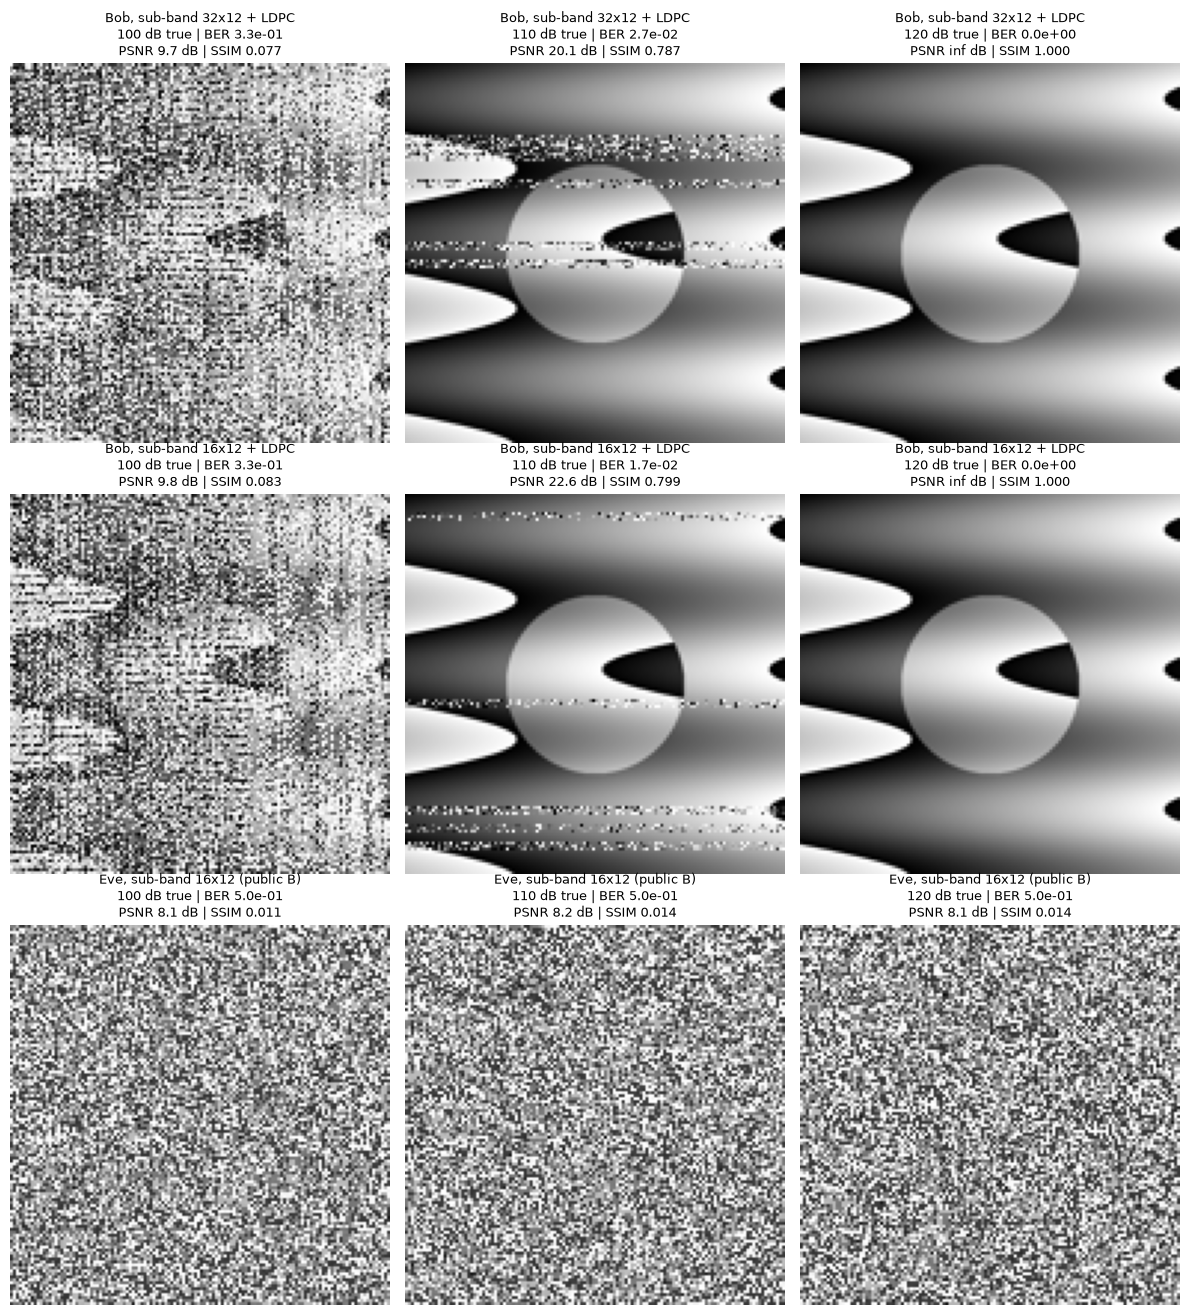

In [17]:
IMG_EBNO = [100, 110, 120]
rows = [("Bob, sub-band 32x12 + LDPC", dict(band_width=32, band_time=12, use_ldpc=True)),
        ("Bob, sub-band 16x12 + LDPC", dict(band_width=16, band_time=12, use_ldpc=True)),
        ("Eve, sub-band 16x12 (public B)", dict(band_width=16, band_time=12, eve=True))]
fig, axes = plt.subplots(len(rows), len(IMG_EBNO), figsize=(4 * len(IMG_EBNO), 4.4 * len(rows)))
for r, (label, kw) in enumerate(rows):
    m = SubbandModel("umi", distinct_bases=True, normalize_power=True, **kw)
    if torch.cuda.is_available(): m.cuda()
    m._channel_model.allocate_topology_tensors(batch_size=16, num_bs=1, num_ut=m._num_ut)
    for c, e in enumerate(IMG_EBNO):
        rx_bits = send_image_bits(m, bits, e)
        rx = np.packbits(rx_bits.astype(np.uint8)).reshape(res, res)
        ber_img = float(np.mean(rx_bits != bits)); p = psnr(img, rx)
        s = ssim(img, rx, data_range=255) if ssim else float("nan")
        axes[r, c].imshow(rx, cmap="gray", vmin=0, vmax=255); axes[r, c].axis("off")
        axes[r, c].set_title(f"{label}\n{e} dB true | BER {ber_img:.1e}\nPSNR {p:.1f} dB | SSIM {s:.3f}", fontsize=9)
        print(f"{label:32s} {e:>4} dB  BER={ber_img:.2e}  PSNR={p:6.2f}  SSIM={s:.4f}")
plt.tight_layout(); plt.show()

## Part D. Scenario checks from Liu et al. (2026), "Keyless Physical-Layer Cryptography"

*S. Liu, D. Cai, D. Han, H. Liu, X. Lu, ISC 2025, LNCS 16186, pp. 24–44, Springer 2026. [doi:10.1007/978-3-032-08124-7_2](https://doi.org/10.1007/978-3-032-08124-7_2)*

**What the paper does.**
- **The channel is the lattice.** Alice (N antennas) computes the SVD H = UΣVᴴ, sends s = V·x with x drawn from a QAM ("interval-encoded") lattice, and Bob computes Uᴴy = Σx + e₁. Σ is a diagonal (orthogonal) basis, so Babai / CVP decoding costs only O(N) (Algorithm 1).
- **Eve gets a noisy channel, not a bad basis.** All legitimate users transmit DFT-based pilots at the same time in full duplex. The stacked pilot matrix is rank-deficient, so Eve cannot estimate her channel. Her error is ΔH ~ CN(0, (P₁−1)/(1+M·P₁)) → 1/M (Lemma 1, M = number of legitimate users).
- **Security as BDD.** Bob decodes if ‖e₁‖ ≤ λ₁/2 (Eq. 10). Eve's equivalent noise ΔH·s + e′ **grows with the signal power**, and once it exceeds the covering radius μ(Λ), her problem is BDD beyond μ (Eq. 16). They report Eve's BER ≈ 0.5 for any SNR (Fig. 7, USRP B210 2×2 BPSK; Fig. 8, MATLAB).

**Why it matters for our story.**
| | GGH (Part A–C) | Liu et al. 2026 (keyless) | ML-KEM / FrodoKEM (mother notebook) |
|---|---|---|---|
| What Eve lacks | the good basis R | an accurate channel estimate | the secret s / session key K |
| What is transmitted | huge C = S·Bᵀ + E | normal QAM (s = V·x) | bounded v ∈ [−q/2, q/2) |
| SNR Bob needs | ≈ 110–120 dB | 0–20 dB | 0–15 dB (5–10 dB with LDPC) |
| Security rests on | GGH hardness (broken) | channel-estimation model, passive Eve, full duplex, CSI at Alice | standardised (Module-)LWE |

The paper confirms the key lesson: **lattice decoding at the PHY works at realistic SNR as long as the transmitted points are not inflated**. GGH pays for security with transmit power. Liu pays with channel assumptions. Standard LWE pays with a small, bounded mod-q noise.

**Checks below** (same UMi model as above; one user with 4 antennas → BS with 8 antennas, one channel use per subcarrier as in the paper's Remark 3):
1. Bob's and Eve's BER vs SNR for 4-QAM / 16-QAM and M ∈ {2, 4, 8} (their Fig. 7/8).
2. BDD check: how often Bob satisfies ‖e₁‖ < λ₁/2, and how often Eve's error exceeds the covering radius μ(Λ).
3. Dimension check: does Eve approach BER 0.5 when the number of antennas N grows (i.i.d. Rayleigh, as in the paper's MATLAB part)?

In [18]:
def umi_su_mimo_channels(batch=64, num_ut_ant=4, num_bs_ant=8, scenario="umi"):
    """Per-subcarrier MIMO matrices H [batch*128, num_bs_ant, num_ut_ant] for ONE multi-antenna UE (3GPP UMi)."""
    ut = AntennaArray(num_rows=1, num_cols=num_ut_ant // 2, polarization="dual", polarization_type="cross",
                      antenna_pattern="omni", carrier_frequency=3.5e9)
    bs = AntennaArray(num_rows=1, num_cols=num_bs_ant // 2, polarization="dual", polarization_type="cross",
                      antenna_pattern="38.901", carrier_frequency=3.5e9)
    ch = UMi(carrier_frequency=3.5e9, o2i_model="low", ut_array=ut, bs_array=bs, direction="uplink",
             enable_pathloss=False, enable_shadow_fading=False)
    ch.set_topology(*gen_topology(batch, 1, scenario, min_ut_velocity=0.0, max_ut_velocity=0.0))
    a, tau = ch(1, 1)
    h = cir_to_ofdm_channel(subcarrier_frequencies(128, 30e3), a, tau, normalize=True)
    return h[:, 0, :, 0, :, 0, :].permute(0, 3, 1, 2).reshape(-1, num_bs_ant, num_ut_ant)

def iid_channels(K, N):
    return ((torch.randn(K, N, N) + 1j * torch.randn(K, N, N)) / np.sqrt(2)).to(torch.complex128)

def liu_keyless(H, snr_db, bits=4, M=4, P1=1e3, eve=False):
    """Liu et al. 2026, Sec. 3.2 + Algorithm 1.
    Alice: s = V x (SVD of the legitimate channel), unit power per antenna.
    Bob:   U^H y = Sigma x + e1  ->  Babai on the diagonal basis Sigma (per-stream rounding, O(N)).
    Eve (worst case, knows H): y_e = (H + dH) s + e',  dH ~ CN(0, (P1-1)/(1+M*P1))  (Lemma 1).
    Returns BER and the error vectors needed for the BDD check."""
    K, Nr, Nt = H.shape
    mapper = Mapper("qam", bits, dtype=torch.complex128)
    demapper = Demapper("app", "qam", bits, hard_out=True, dtype=torch.float64)
    b = BinarySource()([K, Nt * bits]).to(torch.float64)
    x = mapper(b)                                                   # unit-power QAM, [K, Nt]
    U, S, Vh = torch.linalg.svd(H, full_matrices=False)
    s = (Vh.mH @ x.unsqueeze(-1)).squeeze(-1)
    no = 10 ** (-snr_db / 10)
    noise = np.sqrt(no / 2) * (torch.randn(K, Nr) + 1j * torch.randn(K, Nr))
    Hc = H
    if eve:
        var = (P1 - 1) / (1 + M * P1)
        Hc = H + np.sqrt(var / 2) * (torch.randn(H.shape) + 1j * torch.randn(H.shape))
    z = (U.mH @ (Hc @ s.unsqueeze(-1) + noise.unsqueeze(-1))).squeeze(-1)   # = Sigma x + e
    e = z - S * x                                                   # BDD error in Bob's frame
    b_hat = demapper(z / S, torch.tensor(no))                        # Babai on the diagonal basis
    ber = (b_hat != b).double().mean().item()
    return ber, e, S

H_umi = umi_su_mimo_channels(batch=64)
print("UMi channel uses:", H_umi.shape[0], "| H size:", tuple(H_umi.shape[1:]),
      "| mean |h|^2 =", round((H_umi.abs() ** 2).mean().item(), 3))

UMi channel uses: 8192 | H size: (8, 4) | mean |h|^2 = 1.0


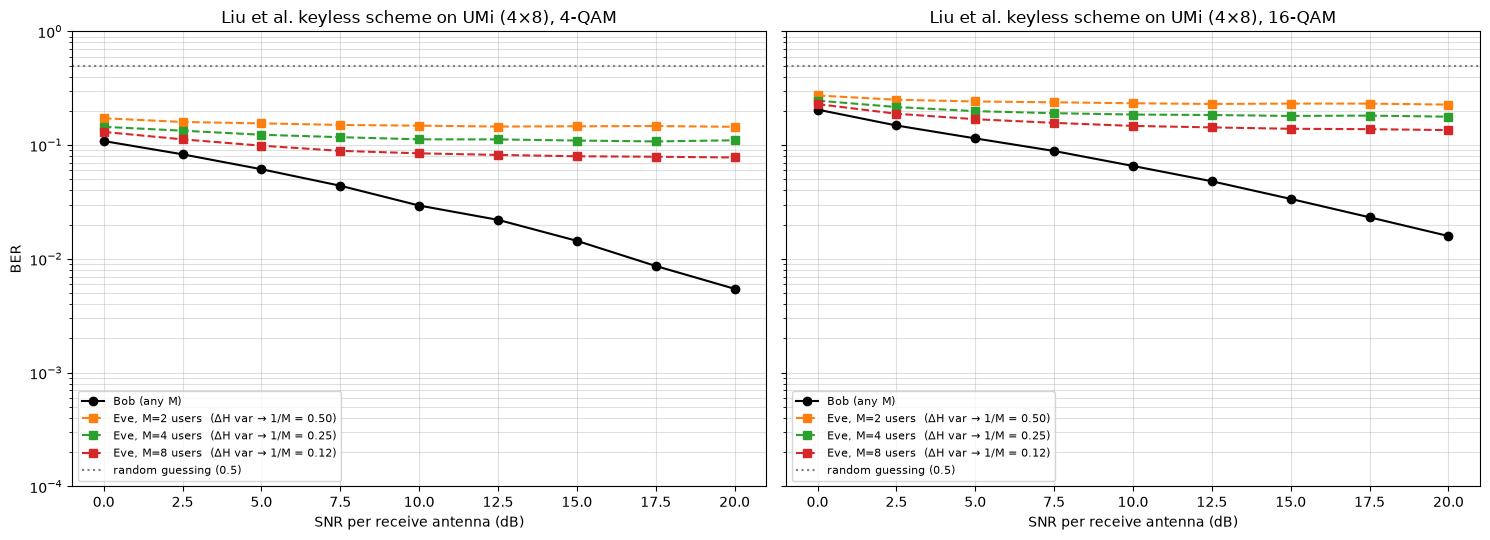

                          0.0    2.5    5.0    7.5   10.0   12.5   15.0   17.5   20.0
  4-QAM M=2 Eve        0.172  0.160  0.155  0.150  0.148  0.146  0.146  0.147  0.145
  4-QAM M=4 Bob        0.109  0.083  0.061  0.044  0.029  0.022  0.014  0.009  0.005
  4-QAM M=4 Eve        0.145  0.134  0.123  0.117  0.112  0.112  0.110  0.108  0.110
  4-QAM M=8 Eve        0.131  0.112  0.099  0.089  0.085  0.082  0.080  0.079  0.078
 16-QAM M=2 Eve        0.273  0.251  0.242  0.238  0.233  0.230  0.232  0.232  0.227
 16-QAM M=4 Bob        0.205  0.149  0.115  0.089  0.066  0.048  0.034  0.023  0.016
 16-QAM M=4 Eve        0.246  0.216  0.199  0.191  0.186  0.184  0.181  0.182  0.178
 16-QAM M=8 Eve        0.229  0.189  0.169  0.157  0.147  0.143  0.139  0.138  0.136


In [19]:
LIU = {"snr_db": list(np.arange(0, 20.1, 2.5)), "results": {}}
for bits in [2, 4]:
    for M in [2, 4, 8]:
        LIU["results"][(bits, M, "Bob")] = [liu_keyless(H_umi, e, bits, M)[0] for e in LIU["snr_db"]]
        LIU["results"][(bits, M, "Eve")] = [liu_keyless(H_umi, e, bits, M, eve=True)[0] for e in LIU["snr_db"]]

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for a, bits in zip(ax, [2, 4]):
    a.semilogy(LIU["snr_db"], LIU["results"][(bits, 4, "Bob")], "-o", color="k", label="Bob (any M)")
    for i, M in enumerate([2, 4, 8]):
        a.semilogy(LIU["snr_db"], LIU["results"][(bits, M, "Eve")], "--s", color=cmap(i + 1),
                   label=f"Eve, M={M} users  (ΔH var → 1/M = {1/M:.2f})")
    a.axhline(0.5, color="gray", ls=":", label="random guessing (0.5)")
    a.set_title(f"Liu et al. keyless scheme on UMi (4×8), {2**bits}-QAM")
    a.set_xlabel("SNR per receive antenna (dB)"); a.grid(True, which="both", alpha=0.4); a.legend(fontsize=8)
ax[0].set_ylabel("BER"); ax[0].set_ylim(1e-4, 1)
plt.tight_layout(); plt.show()

print(f"{'':22s}" + "".join(f"{e:>7.1f}" for e in LIU["snr_db"]))
for (bits, M, who), v in LIU["results"].items():
    if who == "Bob" and M != 4: continue
    print(f"{2**bits:>3d}-QAM M={M} {who:4s}     " + "".join(f"{x:7.3f}" for x in v))

### BDD / covering-radius check (paper Eqs. 10, 16–17)

In Bob's frame the lattice is Σ·x with QAM spacing d. Its shortest vector is λ₁ = d·min σᵢ, and for an orthogonal basis the covering radius is μ = ½·√(Σ ‖bᵢ‖²) = d·√(Σσᵢ²/2).
- **Bob's guarantee (Eq. 10):** ‖e₁‖ ≤ λ₁/2. This is sufficient but very conservative; per-stream rounding usually succeeds even when it fails.
- **Eve's hardness boundary (Eq. 16):** ‖ΔH·s + e′‖ ≥ μ(Λ).

The table gives the fraction of channel uses that meet each condition. If Eve's fraction stays well below 1 at realistic SNR, her failure is statistical (like extra noise), not a guaranteed hardness.

In [20]:
d = 2 / np.sqrt(10)                                  # 16-QAM spacing at unit power
print(f"{'SNR (dB)':>9s}{'Bob ‖e‖<λ1/2':>16s}{'Bob BER':>10s}{'Eve ‖e‖>μ (M=4)':>18s}{'Eve BER':>10s}")
for snr in [0, 5, 10, 15, 20]:
    ber_b, e_b, S = liu_keyless(H_umi, snr, 4, 4)
    ber_e, e_e, _ = liu_keyless(H_umi, snr, 4, 4, eve=True)
    lam1 = d * S.min(-1).values
    mu = d * torch.sqrt((S ** 2).sum(-1) / 2)
    bob_ok = (e_b.norm(dim=-1) < lam1 / 2).double().mean().item()
    eve_hard = (e_e.norm(dim=-1) > mu).double().mean().item()
    print(f"{snr:9.0f}{bob_ok:16.3f}{ber_b:10.3f}{eve_hard:18.3f}{ber_e:10.3f}")

 SNR (dB)    Bob ‖e‖<λ1/2   Bob BER   Eve ‖e‖>μ (M=4)   Eve BER
        0           0.000     0.205             0.594     0.246
        5           0.000     0.115             0.299     0.200


       10           0.010     0.066             0.193     0.187
       15           0.140     0.033             0.174     0.183
       20           0.509     0.016             0.160     0.181


In [21]:
# Dimension check (paper: "the number of antennas corresponds to the dimension of the lattice")
print("i.i.d. Rayleigh N x N, 16-QAM, SNR = 20 dB")
print(f"{'N':>5s}{'Bob BER':>10s}" + "".join(f"{'Eve BER M='+str(M):>14s}" for M in [2, 4, 8]))
for N in [4, 16, 64]:
    H = iid_channels(4096 // N * 4, N)
    row = f"{N:5d}{liu_keyless(H, 20, 4, 4)[0]:10.4f}"
    row += "".join(f"{liu_keyless(H, 20, 4, M, eve=True)[0]:14.3f}" for M in [2, 4, 8])
    print(row)

i.i.d. Rayleigh N x N, 16-QAM, SNR = 20 dB
    N   Bob BER   Eve BER M=2   Eve BER M=4   Eve BER M=8


    4    0.0160         0.266         0.209         0.157


   16    0.0107         0.273         0.217         0.165


   64    0.0054         0.274         0.216         0.164


**Reading the Liu checks.**
- **What confirms the paper:** Bob decodes at ordinary SNRs with O(N) Babai on the diagonal basis Σ. Eve's BER **does not fall with SNR**, because her equivalent error ΔH·s scales with the signal (paper Fig. 7).
- **What does not reach the paper's claim here:** with the paper's own error model (ΔH variance → 1/M) on a 4 × 8 UMi channel, Eve's BER levels off well **below 0.5**. It is worse for her with fewer users M, and the dimension check suggests that larger N alone does not fix this. Eve's failure is driven by the ratio of signal to ΔH power (≈ M), so a stricter hardness proof or a larger constellation spacing (the paper's condition a ≥ √M/4) is needed.
- **Assumptions to keep in mind:** passive Eve, full-duplex pilots by all users, CSI at Alice for SVD precoding, point-to-point MIMO (not our single-antenna multi-user uplink), and a line of MIMO-cryptography work that has been attacked before (Dean–Goldsmith → Sakzad–Steinfeld 2020; Yang Li 2026).

**What we reuse from the paper:**
1. the **BDD language**: Bob inside λ₁/2, Eve beyond the covering radius;
2. **Eve's BER vs SNR** (and vs antennas or modulation) as the confidentiality metric;
3. "**each channel use / tile is one lattice instance**" (their Remark 3), which matches our sub-band tiles;
4. the **USRP B210** set-up as a template for a future over-the-air test.

We do **not** adopt the keyless security model. For our uplink, a standardised computational assumption (Module-LWE) is cleaner.

## Part E. Outlook: what a standardised lattice scheme changes (teaser for the mother notebook)

Standardised LWE schemes work **modulo q**, so every transmitted value lies in [−q/2, q/2) and the transmit power is fixed whatever the security level. Bob succeeds if |LWE noise + channel noise| < q/2^(bits+1). The table below uses the standard parameters. The GGH number comes from the security-vs-SNR sweep in Part B (secure keys only).

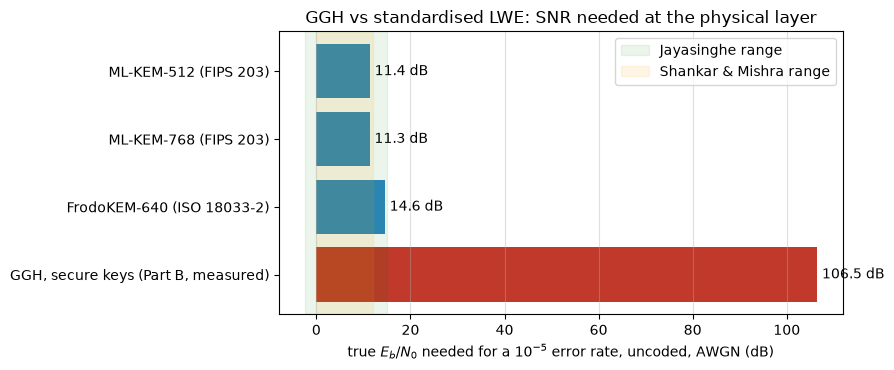

In [22]:
from statistics import NormalDist
def lwe_required_esno(q, bits, lwe_var, p=1e-5):
    margin = q / 2 ** (bits + 1)
    g = NormalDist().inv_cdf(1 - p / 2)
    no = (margin ** 2 / g ** 2 - lwe_var) / (q ** 2 / 12)          # channel noise allowed at unit power
    return -10 * np.log10(no)

schemes = {  # name: (q, message bits per coefficient, LWE decryption-noise variance)
    "ML-KEM-512 (FIPS 203)":    (3329, 1, 512 * 1.5 * 1.5 + 512 * 1.5 * 1.0 + 1.0),
    "ML-KEM-768 (FIPS 203)":    (3329, 1, 768 * 1.0 * 1.0 + 768 * 1.0 * 1.0 + 1.0),
    "FrodoKEM-640 (ISO 18033-2)": (2 ** 15, 2, 2 * 640 * 2.8 ** 4 + 2.8 ** 2),
}
req = {name: lwe_required_esno(*v) - 10 * np.log10(2 * v[1]) for name, v in schemes.items()}   # Eb/N0
ggh_secure = [r["snr_req"] - 10 * np.log10(4) for r in SEC if r["secure"] and np.isfinite(r["snr_req"])]
req["GGH, secure keys (Part B, measured)"] = float(np.min(ggh_secure)) if ggh_secure else float("nan")

fig, ax = plt.subplots(figsize=(9, 3.8))
names = list(req)[::-1]
ax.barh(names, [req[n] for n in names], color=["#c0392b" if "GGH" in n else "#2e86c1" for n in names])
for i, n in enumerate(names):
    ax.text(req[n] + 1, i, f"{req[n]:.1f} dB", va="center")
ax.axvspan(-2.5, 15, color="green", alpha=0.08, label="Jayasinghe range")
ax.axvspan(0, 12, color="orange", alpha=0.10, label="Shankar & Mishra range")
ax.set_xlabel(r"true $E_b/N_0$ needed for a 10$^{-5}$ error rate, uncoded, AWGN (dB)")
ax.set_title("GGH vs standardised LWE: SNR needed at the physical layer"); ax.legend(loc="upper right")
ax.grid(True, axis="x", alpha=0.4); plt.tight_layout(); plt.show()

**Next step.** The mother notebook (`PQC_MIMO_Simulations_subband.ipynb`) implements ML-KEM and FrodoKEM per sub-band tile over the same UMi uplink. With LDPC 1/2, Bob reaches BER 0 at about 7.5–10 dB true Eb/N0, and Eve stays at 0.5. Which standard to adopt (ML-KEM for the NIST ecosystem, FrodoKEM for a conservative plain-LWE option) is the open choice to discuss.